In [1]:
import boto3
import json
from IPython.display import JSON

MODEL_ID = "amazon.nova-lite-v1:0"
bedrock = boto3.client(service_name='bedrock-runtime', region_name='us-east-1')

response = bedrock.invoke_model(
modelId=MODEL_ID,
body=json.dumps({
"schemaVersion": "messages-v1",
"messages": [{"role": "user", "content": [{"text": "Rewrite this sentence for me in a formal tone: What time can you do lunch tomorrow?"}]}],
"inferenceConfig": {"maxTokens": 500, "topK": 20, "temperature": 0.7}
})
)

JSON(json.loads(response['body'].read().decode()), expanded=True)

<IPython.core.display.JSON object>

In [2]:
response = bedrock.converse(
modelId=MODEL_ID,
messages=[{
"role": "user",
"content": [{"text": "Rewrite this sentence for me in a formal tone: What time can you do lunch tomorrow?"}]
}]
)

JSON(response['output'], expanded=True)

<IPython.core.display.JSON object>

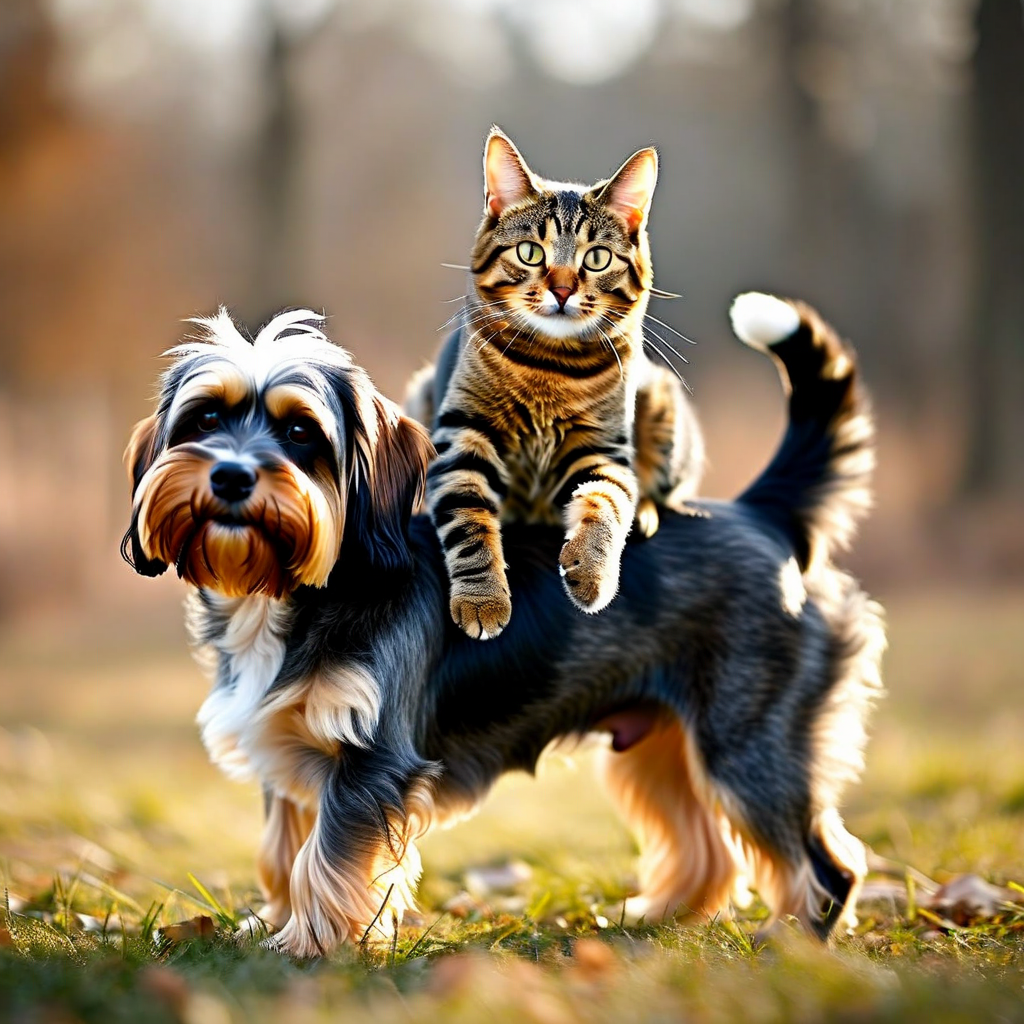

In [3]:
from IPython.display import Image
import base64
import json

MODEL_ID = "amazon.nova-canvas-v1:0"

response = bedrock.invoke_model(
modelId=MODEL_ID,
body=json.dumps({
"taskType": "TEXT_IMAGE",
"textToImageParams": {
    "text": "A cat riding a dog"
},
"imageGenerationConfig": {
    "numberOfImages": 1,
    "height": 1024,
    "width": 1024,
    "cfgScale": 8.0
}
})
)

response_body = json.loads(response.get("body").read())
base64_image = response_body.get("images")[0].encode('ascii')
image_bytes = base64.b64decode(base64_image)
Image(data=image_bytes)